# Setup

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# Load and inspect 

In [2]:
DATA_PATH = "../data/raw/dataset_100k_10dp.csv"
df = pd.read_csv(DATA_PATH)

In [3]:
print(df.shape)
print(df.columns.values)

(100000, 12)
['VIDEO_ID' 'TITLE' 'DESCRIPTION' 'VIDEO_DURATION' 'VIDEO_PUBLISHED_AT'
 'VPH' 'LIKES' 'VIEWS' 'COMMENTS' 'CHANNEL_SUBSCRIBERS' 'SCRAPE_TIME'
 'FUTURE_VIEWS']


In [4]:
print(df.dtypes) # Need to change dates to datetime

VIDEO_ID               object
TITLE                  object
DESCRIPTION            object
VIDEO_DURATION          int64
VIDEO_PUBLISHED_AT     object
VPH                     int64
LIKES                   int64
VIEWS                   int64
COMMENTS                int64
CHANNEL_SUBSCRIBERS     int64
SCRAPE_TIME            object
FUTURE_VIEWS            int64
dtype: object


In [5]:
np.round(df.describe().T)
# min FUTURE_VIEWS 0 is weird, need to investigate further down. 

,count,mean,std,min,25%,50%,75%,max
VIDEO_DURATION,100000.0,214.0,940.0,0.0,16.0,33.0,59.0,20853.0
VPH,100000.0,1377.0,9619.0,0.0,38.0,242.0,935.0,1529909.0
LIKES,100000.0,5477.0,57146.0,0.0,16.0,114.0,619.0,2280899.0
VIEWS,100000.0,87447.0,1019360.0,0.0,56.0,349.0,1537.0,34017757.0
COMMENTS,100000.0,84.0,1016.0,0.0,0.0,4.0,20.0,50775.0
CHANNEL_SUBSCRIBERS,100000.0,2431488.0,5148630.0,867.0,153000.0,652000.0,2380000.0,111000000.0
FUTURE_VIEWS,100000.0,504125.0,2139626.0,0.0,7735.0,34193.0,231237.0,86261435.0


In [6]:
df.head()

,VIDEO_ID,TITLE,DESCRIPTION,VIDEO_DURATION,VIDEO_PUBLISHED_AT,VPH,LIKES,VIEWS,COMMENTS,CHANNEL_SUBSCRIBERS,SCRAPE_TIME,FUTURE_VIEWS
0,--3bV2e-NKE,A Girl's Ego | My Hero Academia S7 Ep 20 Reaction,PATREON📺: http://Patreon.com/Yaboyroshi\nCHECK...,823,2024-10-08 22:00:00.000,7392,374,2477,64,901000,2024-10-08 22:20:26.467,70718
1,--3bV2e-NKE,A Girl's Ego | My Hero Academia S7 Ep 20 Reaction,PATREON📺: http://Patreon.com/Yaboyroshi\nCHECK...,823,2024-10-08 22:00:00.000,6747,509,3386,92,901000,2024-10-08 22:30:25.600,70718
2,--3bV2e-NKE,A Girl's Ego | My Hero Academia S7 Ep 20 Reaction,PATREON📺: http://Patreon.com/Yaboyroshi\nCHECK...,823,2024-10-08 22:00:00.000,5704,638,3813,113,901000,2024-10-08 22:40:41.970,70718
3,--3bV2e-NKE,A Girl's Ego | My Hero Academia S7 Ep 20 Reaction,PATREON📺: http://Patreon.com/Yaboyroshi\nCHECK...,823,2024-10-08 22:00:00.000,4981,764,4155,127,901000,2024-10-08 22:50:04.306,70718
4,--3bV2e-NKE,A Girl's Ego | My Hero Academia S7 Ep 20 Reaction,PATREON📺: http://Patreon.com/Yaboyroshi\nCHECK...,823,2024-10-08 22:00:00.000,4329,909,4513,138,901000,2024-10-08 23:02:58.117,70718


In [7]:
df['SCRAPE_TIME'] = pd.to_datetime(df['SCRAPE_TIME'])
df['VIDEO_PUBLISHED_AT'] = pd.to_datetime(df['VIDEO_PUBLISHED_AT'])

### Temporal panel validation

In [8]:
print(f"Number of unique videos: {df['VIDEO_ID'].nunique()}\n")
print(df.groupby('VIDEO_ID').size().describe())

# Almost fixed length sequences. ~10 obs per video.
# I can A) Treat is a fix length (simplification)
# or B) Treat the problem as variable length (more complex).

Number of unique videos: 10003

count    10003.000000
mean         9.997001
std          0.113967
min          3.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         10.000000
dtype: float64


In [9]:
df_sorted = df.sort_values(['VIDEO_ID', 'SCRAPE_TIME'])

In [10]:
df_sorted = df.sort_values(['VIDEO_ID', 'SCRAPE_TIME'])
def check_time_order(group):
    return (group['SCRAPE_TIME'].diff().dropna() < pd.Timedelta(0)).any()

time_issues = df_sorted.groupby('VIDEO_ID').apply(check_time_order)
print(f"Videos with time ordering issues: {time_issues.sum()}")

Videos with time ordering issues: 0


/var/folders/8w/zmlxvyj52l7_fdlcpjyc4rd40000gn/T/ipykernel_80898/1154702416.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_issues = df_sorted.groupby('VIDEO_ID').apply(check_time_order)


In [11]:
df_sorted['TIME_IDX'] = df_sorted.groupby('VIDEO_ID').cumcount()
df_sorted[['VIDEO_ID', 'SCRAPE_TIME', 'TIME_IDX']].head(10)

,VIDEO_ID,SCRAPE_TIME,TIME_IDX
0,--3bV2e-NKE,2024-10-08 22:20:26.467,0
1,--3bV2e-NKE,2024-10-08 22:30:25.600,1
2,--3bV2e-NKE,2024-10-08 22:40:41.970,2
3,--3bV2e-NKE,2024-10-08 22:50:04.306,3
4,--3bV2e-NKE,2024-10-08 23:02:58.117,4
5,--3bV2e-NKE,2024-10-08 23:10:22.586,5
6,--3bV2e-NKE,2024-10-08 23:20:27.978,6
7,--3bV2e-NKE,2024-10-08 23:30:27.877,7
8,--3bV2e-NKE,2024-10-08 23:40:17.493,8
9,--3bV2e-NKE,2024-10-08 23:50:19.915,9


# Target Sanity Checks

In [12]:
violations = (df_sorted['FUTURE_VIEWS'] < df_sorted['VIEWS']).sum()
print(f"Number of violations (future < current): {violations}")

# small number of inconsistencies, most likely noise or different definitions(?)
# Nope: we have some problmes with zeros. There are videos with 0 future_views which could be fine, but:
# There are also some with 0 DURATION and positive VPH, LIKES, and FUTURE_VIEWS.  

Number of violations (future < current): 82


In [13]:
sample_videos = df_sorted['VIDEO_ID'].drop_duplicates().sample(3, random_state=42)

for vid in sample_videos:
    print(f"\nVideo: {vid}")
    display(df_sorted[df_sorted['VIDEO_ID'] == vid][
        ['TIME_IDX', 'VIEWS', 'FUTURE_VIEWS']
    ])

# Almost fixed future horizon - not rolling



Video: 3UEujXTKWHc


,TIME_IDX,VIEWS,FUTURE_VIEWS
68817,0,1351,36786
68818,1,1357,36786
68819,2,1358,36786
68820,3,1369,36786
68821,4,1383,36786
68822,5,1403,36786
68823,6,1476,36786
68824,7,2000,36786
68825,8,2058,36786
68826,9,2060,36786



Video: 2nfiIeb_teg


,TIME_IDX,VIEWS,FUTURE_VIEWS
58348,0,964,337675
58349,1,1078,335500
58350,2,1085,335500
58351,3,1086,335500
58352,4,1100,335500
58353,5,1130,335500
58354,6,1172,335500
58355,7,3542,335500
58356,8,13527,335500
58357,9,13565,335500



Video: 4YUtwDaqzyw


,TIME_IDX,VIEWS,FUTURE_VIEWS
85996,0,8,626
85997,1,60,626
85998,2,99,626
85999,3,126,626
86000,4,156,626
86001,5,200,626
86002,6,204,626
86003,7,220,626
86004,8,236,626
86005,9,249,626


In [14]:
corr = df_sorted[['VIEWS', 'FUTURE_VIEWS']].corr()
print("\nCorrelation:\n", corr)

# 46%. Current views matter but other growth dynamics matter too. 


Correlation:
                  VIEWS  FUTURE_VIEWS
VIEWS         1.000000      0.468074
FUTURE_VIEWS  0.468074      1.000000


# Missing Values

In [15]:
print("Missing values:\n")
print(df_sorted.isnull().sum())

Missing values:

VIDEO_ID                   0
TITLE                      0
DESCRIPTION            49812
VIDEO_DURATION             0
VIDEO_PUBLISHED_AT         0
VPH                        0
LIKES                      0
VIEWS                      0
COMMENTS                   0
CHANNEL_SUBSCRIBERS        0
SCRAPE_TIME                0
FUTURE_VIEWS               0
TIME_IDX                   0
dtype: int64


# Distributions

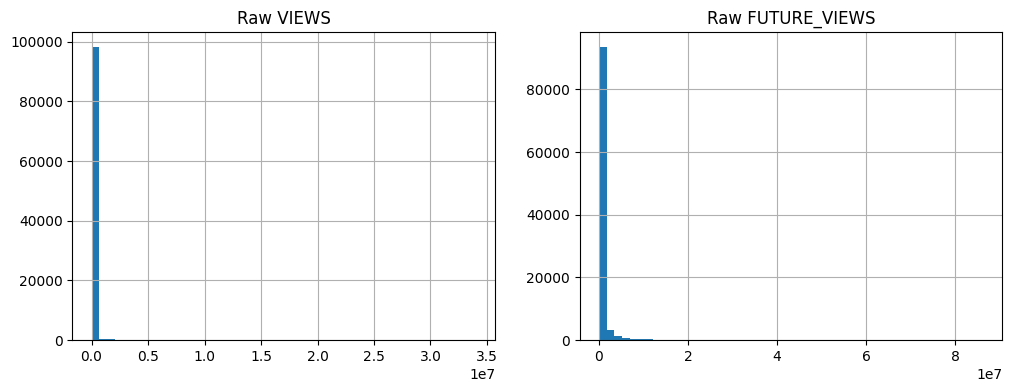

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_sorted['VIEWS'].hist(bins=50, ax=axes[0])
axes[0].set_title("Raw VIEWS")

df_sorted['FUTURE_VIEWS'].hist(bins=50, ax=axes[1])
axes[1].set_title("Raw FUTURE_VIEWS")

plt.show()

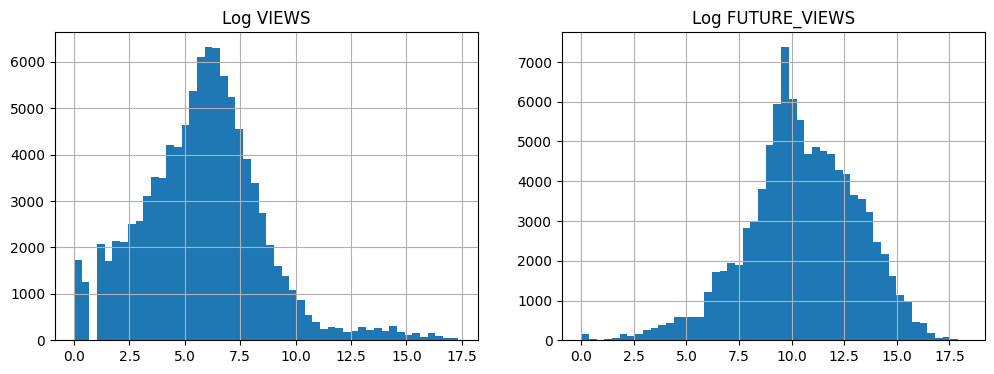

In [17]:
df_sorted['log_views'] = np.log1p(df_sorted['VIEWS'])
df_sorted['log_future_views'] = np.log1p(df_sorted['FUTURE_VIEWS'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_sorted['log_views'].hist(bins=50, ax=axes[0])
axes[0].set_title("Log VIEWS")

df_sorted['log_future_views'].hist(bins=50, ax=axes[1])
axes[1].set_title("Log FUTURE_VIEWS")

plt.show()

# Sanity Plots

In [18]:
seq_lengths = df_sorted.groupby('VIDEO_ID').size()
print("Sequence length distribution:\n")
print(seq_lengths.value_counts().sort_index())

# I thikn that we can drop the less than 10 to be honest

Sequence length distribution:

3        1
4        1
5        1
7        1
8        1
9        7
10    9991
Name: count, dtype: int64


In [19]:
total_prefixes = seq_lengths.sum()
print(f"\nTotal prefix examples (should match dataset size): {total_prefixes}, {total_prefixes==df.shape[0]}")

# so at time t, the VIEWS column show the whole history up until this time. The dataset is ready to be analyzed in this form. 


Total prefix examples (should match dataset size): 100000, True


In [20]:
time_diffs = df_sorted.groupby('VIDEO_ID')['SCRAPE_TIME'].diff().dt.total_seconds() / 60

print("\nTime gap summary:")
print(time_diffs.describe())


Time gap summary:
count    89997.000000
mean         8.274118
std          7.894258
min          0.014833
25%          1.663600
50%          9.543500
75%         10.157317
max        481.096650
Name: SCRAPE_TIME, dtype: float64


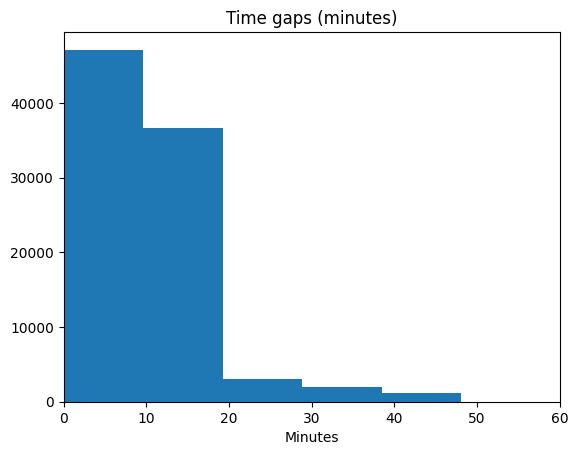

In [21]:
plt.hist(time_diffs, bins=50)
plt.title("Time gaps (minutes)")
plt.xlabel("Minutes")
plt.xlim(0, 60)
plt.show()

# VIEWS: 100 -> 200 -> 300, but the model desn't know if this happened in 1 second or in 1 hour. 
# Hence, ellapsed time needs to be included as a feature.

# Other Plots

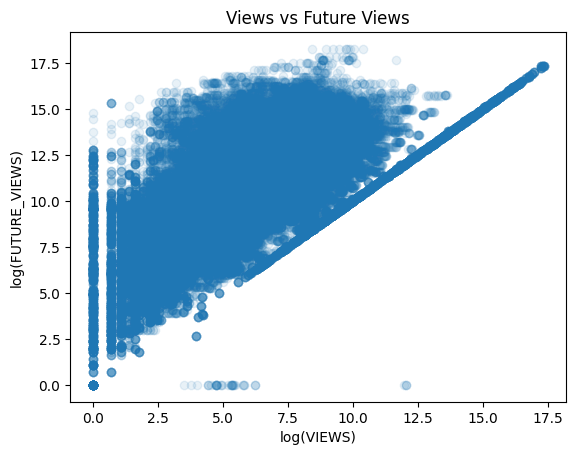

In [22]:
plt.scatter(df_sorted['log_views'], df_sorted['log_future_views'], alpha=0.1)
plt.xlabel("log(VIEWS)")
plt.ylabel("log(FUTURE_VIEWS)")
plt.title("Views vs Future Views")
plt.show()

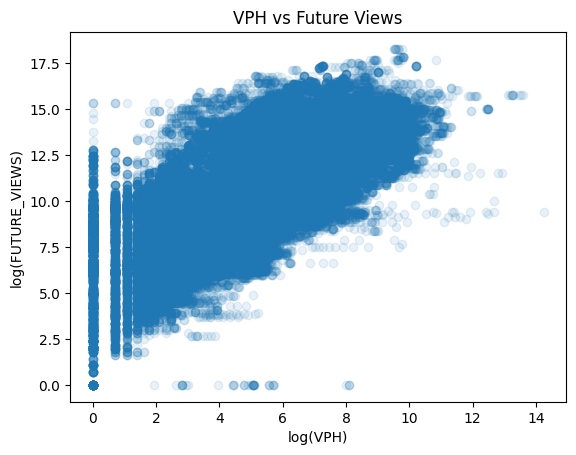

In [23]:
plt.scatter(np.log1p(df_sorted['VPH']), df_sorted['log_future_views'], alpha=0.1)
plt.xlabel("log(VPH)")
plt.ylabel("log(FUTURE_VIEWS)")
plt.title("VPH vs Future Views")
plt.show()

# Zero DURATION and FUTURE_VIEWS investigation

In [24]:
zero_duration = df_sorted[df_sorted['VIDEO_DURATION'] == 0]

print(f"Rows with zero duration: {len(zero_duration)}")

#2450, this is not neglegable

Rows with zero duration: 2450


In [25]:
#all zerolike
cols_to_check = ['VPH', 'LIKES', 'VIEWS', 'COMMENTS', 'FUTURE_VIEWS']

inconsistent_zero_duration = zero_duration[
    (zero_duration[cols_to_check] > 0).any(axis=1) # any of the above columns which are engangement metrics for the sepcific video are non zero. 
]

print(f"Inconsistent zero-duration rows: {len(inconsistent_zero_duration)}")

# Videos that need to be dropped. 

Inconsistent zero-duration rows: 2380


In [26]:
zero_future = df_sorted[df_sorted['FUTURE_VIEWS'] == 0]

print(f"\nRows with FUTURE_VIEWS = 0: {len(zero_future)}")

print("\nSummary stats for zero FUTURE_VIEWS rows:")
print(zero_future[cols_to_check].describe())


Rows with FUTURE_VIEWS = 0: 164

Summary stats for zero FUTURE_VIEWS rows:
               VPH         LIKES          VIEWS    COMMENTS  FUTURE_VIEWS
count   164.000000    164.000000     164.000000  164.000000         164.0
mean    107.853659    870.951220    4206.152439    2.658537           0.0
std     495.702677   3437.431872   26411.775788   12.629423           0.0
min       0.000000      0.000000       0.000000    0.000000           0.0
25%       0.000000      0.000000       0.000000    0.000000           0.0
50%       0.000000      0.000000       0.000000    0.000000           0.0
75%       7.750000     16.000000      34.500000    0.000000           0.0
max    3274.000000  15478.000000  174278.000000   70.000000           0.0


# Results

## 1. Dataset Structure and Panel Validation

The dataset exhibits a clear **panel (longitudinal) structure**, where each `VIDEO_ID` is associated with multiple observations collected at different `SCRAPE_TIME` timestamps.  

- The majority of videos have **10 observations**, with very limited deviation (min = 3, max = 10).  
- Timestamps are **properly ordered within each video**, with no detected temporal inconsistencies.  
- A time index (`TIME_IDX`) was constructed by sorting observations per video and assigning an increasing counter.

**Conclusion:**  
The dataset can be treated as a collection of short temporal sequences with consistent structure across videos.

---

## 2. Interpretation of the Target Variable

The target variable (`FUTURE_VIEWS`) is observed to be **approximately constant within each video across time**, with minor deviations in a few cases.

This suggests that:
- The target corresponds to a **fixed future horizon per video**, rather than a rolling or step-ahead forecast.
- Each row represents a progressively richer observation of the same underlying prediction task.

**Conclusion:**  
The problem is best framed as a **partial-information regression task**, where predictions are refined as more observations become available.

---

## 3. Distributional Properties

Both `VIEWS` and `FUTURE_VIEWS` exhibit **extreme right-skewness**, with large discrepancies between median and maximum values.

- Log-transforming these variables using `log(1 + x)` produces approximately well-behaved distributions.

**Decision:**
- Apply **log-transformation** to both input features (`VIEWS`) and the target (`FUTURE_VIEWS`).

---

## 4. Temporal Characteristics

The time intervals between consecutive observations are **irregular**, ranging from milliseconds to several hours.

- Median gap ≈ 9–10 minutes  
- Significant variability across observations  

**Implication:**
The model cannot assume uniform sampling.

**Decision:**
- Incorporate **time-based features**, such as:
  - time since previous observation  
  - time since first observation  

---

## 5. Data Quality and Anomaly Detection

### 5.1 Zero-Duration Videos

A subset of observations (2450 rows) was identified with `VIDEO_DURATION = 0`.  

- Approximately **97% of these rows contain non-zero engagement metrics** (views, likes, etc.), which is logically inconsistent.
- A video of zero duration cannot realistically accumulate engagement.

**Decision:**
- Remove **entire videos** containing any zero-duration observations.  

**Rationale:**
- Preserves temporal consistency within sequences  
- Avoids partial corruption of video trajectories  
- Assumes measurement issues affect the entire video  

This decision is conservative and prioritises data integrity over sample size. Further investigation into the origin of these anomalies would be required in a production setting.

---

### 5.2 Zero Future Views

A small subset of rows has `FUTURE_VIEWS = 0`.

- Many of these observations exhibit near-zero engagement across features  
- Some contain non-zero values, suggesting potential noise or incomplete tracking  

**Decision:**
- Retain these observations unless additional evidence of corruption is identified  

---

## 6. Feature Selection Decisions

The following columns will be excluded:

- `VIDEO_ID` → identifier only  
- `TITLE` → high cardinality, not suitable for baseline  
- `DESCRIPTION` → high missingness  
- `VIDEO_PUBLISHED_AT` → excluded for baseline (may be revisited)

The following features will be retained:

- `VIDEO_DURATION`  
- `VPH` (log-transformed)
- `LIKES` (log-transformed)
- `VIEWS` (log-transformed)  
- `COMMENTS` (log-transformed)
- `CHANNEL_SUBSCRIBERS` (log-transformed)
- `TIME_IDX`  
- engineered time features (to be added)

---

## 7. Modelling Strategy (Derived from EDA)

Based on the above findings:

1. **Data Splitting**
   - Use **grouped splits by `VIDEO_ID`** to avoid leakage across temporal observations.

2. **Input Representation**
   - Treat each row as a **prefix-based observation**, where later time indices encode richer information.

3. **Target Transformation**
   - Predict `log(1 + FUTURE_VIEWS)`.

4. **Feature Engineering**
   - Include:
     - log-transformed views  
     - temporal features (time gaps, elapsed time)  
     - other features discussed later

5. **Data Cleaning**
   - Remove videos with zero-duration anomalies  
   - Retain zero-target rows unless clearly invalid  

---

## 8. Summary

The dataset is well-structured and suitable for modelling after minimal but targeted cleaning.  
The key characteristics of the problem are:

- short, consistent temporal sequences  
- fixed-horizon target per video  
- irregular time intervals  
- strong skewness in engagement metrics  

The modelling approach will therefore focus on:
- robust regression under skewed distributions  
- leveraging progressively informative observations  
- maintaining strict separation between videos during evaluation

# Misc Ideas

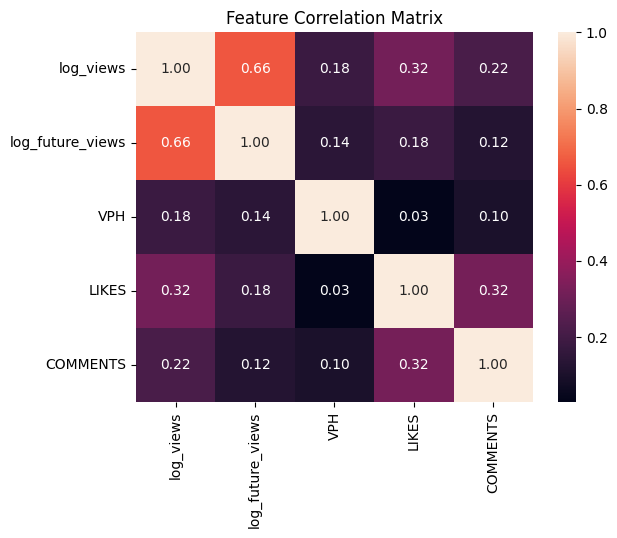

In [27]:
sns.heatmap(df_sorted[
    ['log_views', 'log_future_views', 'VPH', 'LIKES', 'COMMENTS']
].corr(), annot=True, fmt=".2f")

plt.title("Feature Correlation Matrix")
plt.show()

/Users/thodorisladas/Documents/code/orfium/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


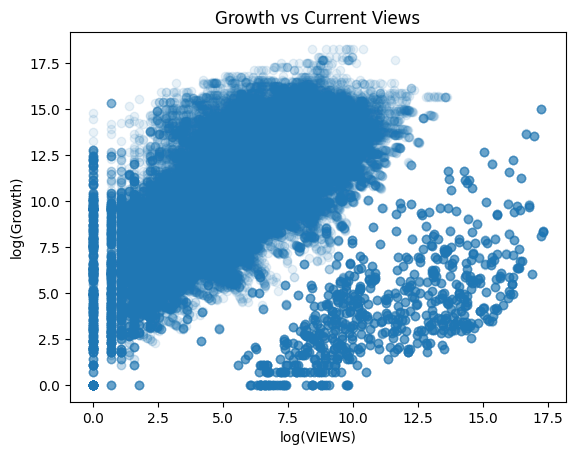

In [28]:
df_sorted['growth'] = df_sorted['FUTURE_VIEWS'] - df_sorted['VIEWS']

plt.scatter(df_sorted['log_views'], np.log1p(df_sorted['growth']), alpha=0.1)
plt.xlabel("log(VIEWS)")
plt.ylabel("log(Growth)")
plt.title("Growth vs Current Views")
plt.show()